In [1]:
import matplotlib.pyplot as plt
import numpy as np
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.datasets import california_housing

(inputs, targets), (x_test, y_test) = california_housing.load_data(version='small', 
                                        test_split=0.2)
print(inputs.shape, targets.shape)
print(x_test.shape, y_test.shape)

I0000 00:00:1774604209.097808   58720 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


(480, 8) (480,)
(120, 8) (120,)


In [2]:
# Extract sets for training and validation
x_train = inputs[:380]
y_train = targets[:380]
x_val = inputs[380:]
y_val = targets[380:]

In [3]:
mean = x_train.mean(axis=0) # mean and standard deviation computed from training set only
std = x_train.std(axis=0)
x_train -= mean
x_train /= std
x_test -= mean
x_test /= std
x_val -= mean
x_val /= std
y_train /= 1e5
y_test /= 1e5
y_val /= 1e5

In [4]:
# define the model architecture
model = Sequential([
    Input(shape=(8,)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
    ])

# configure the learning algorithm
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

I0000 00:00:1774604213.520938   58720 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [5]:
history = model.fit(x_train, y_train, epochs=500, batch_size=32, validation_data=(x_val, y_val), verbose=0)

I0000 00:00:1774604214.775367   58784 service.cc:153] XLA service 0x70ca44032c10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774604214.775408   58784 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 12.8.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774604214.792512   58784 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774604214.888515   58784 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774604214.894810   58784 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1264__.9
I0000 00:00:1774604215.995444   58784 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1774604216.105808   58784 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1264

Text(0, 0.5, 'Loss')

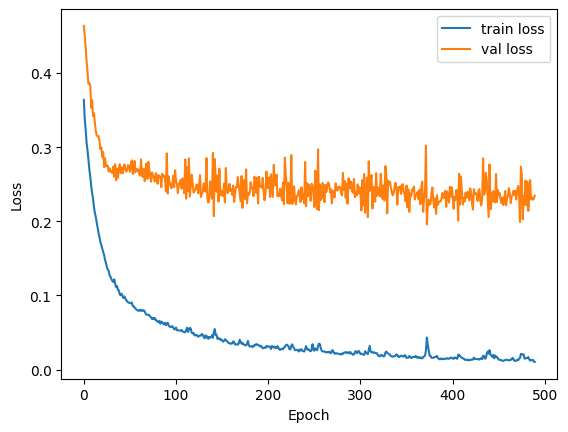

In [6]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

Validation loss increasing while training loss keeps decreases is a sign of overfitting.  
Ideally, both values should go down somewhat in parallel.  

With accuracy, the opposite is desirable, both values should be going up or stabilizing.

In [7]:
from keras.layers import Dropout

model = Sequential([
    Input(shape=(8,)),
    Dense(64, activation='relu'),
    Dropout(0.2), # drop 20% of the outputs
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

In [8]:
# configure the learning algorithm
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

history = model.fit(x_train, y_train, epochs=500, batch_size=32, validation_data=(x_val, y_val), verbose=0)

I0000 00:00:1774604256.606350   58784 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46928__.11
I0000 00:00:1774604257.820200   58783 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46928__.11


Text(0, 0.5, 'Loss')

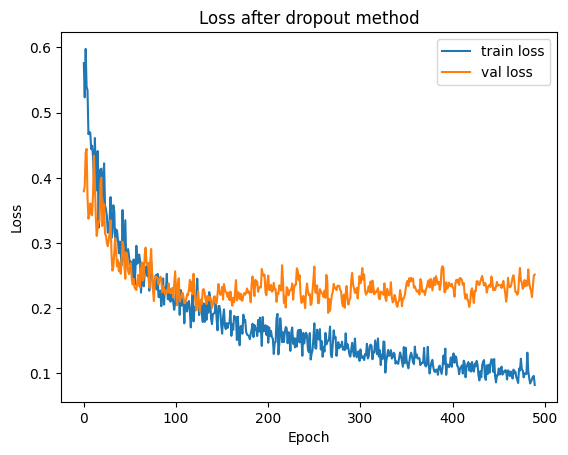

In [9]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.title('Loss after dropout method')
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [10]:
from keras.regularizers import l2

model = Sequential([
    Input(shape=(8,)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1)
])

# configure the learning algorithm
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

history = model.fit(x_train, y_train, epochs=500, batch_size=32, validation_data=(x_val, y_val), verbose=0)

I0000 00:00:1774604300.027788   58780 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_92548__.12
I0000 00:00:1774604300.788029   58782 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_92548__.12


Text(0, 0.5, 'Loss')

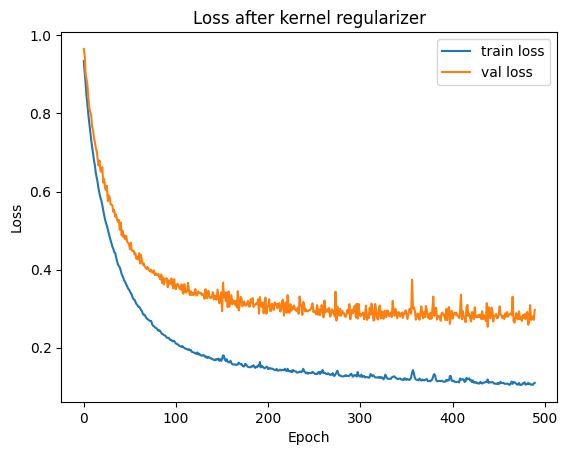

In [11]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.title('Loss after kernel regularizer')
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [12]:
from keras.layers import BatchNormalization

model = Sequential([
    Input(shape=(8,)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(1)
])

# configure the learning algorithm
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

history = model.fit(x_train, y_train, epochs=500, batch_size=32, validation_data=(x_val, y_val), verbose=0)

I0000 00:00:1774604341.832998   58784 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_138945__.21
I0000 00:00:1774604343.188532   58783 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_138945__.21


Text(0, 0.5, 'Loss')

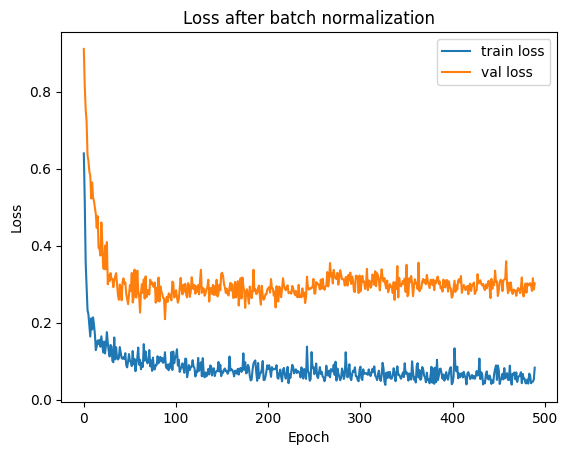

In [13]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.title('Loss after batch normalization')
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [16]:
from keras.callbacks import EarlyStopping

x_train_full = np.concatenate((x_train, x_val), axis=0) # join train + val sets
y_train_full = np.concatenate((y_train, y_val), axis=0)

model = Sequential([
    Input(shape=(8,)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
    ])

model.compile(optimizer='adam',loss='mse',metrics=['mae'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10)
history = model.fit(x_train_full, y_train_full, epochs=500, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/500


I0000 00:00:1774604494.474783   58784 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_184622__.8


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 4.0575 - mae: 1.7337 - val_loss: 2.2313 - val_mae: 1.1935
Epoch 2/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0876 - mae: 1.1319 - val_loss: 1.1027 - val_mae: 0.8014
Epoch 3/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3608 - mae: 0.8624 - val_loss: 0.9099 - val_mae: 0.7499
Epoch 4/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9904 - mae: 0.7565 - val_loss: 0.7504 - val_mae: 0.6717
Epoch 5/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7228 - mae: 0.6566 - val_loss: 0.6602 - val_mae: 0.6364
Epoch 6/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5893 - mae: 0.5825 - val_loss: 0.5744 - val_mae: 0.5899
Epoch 7/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4990 - mae: 0.5338 - val_loss: 0.5535 - val_mae: 0.5736
Epoch 8/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4460 - mae: 0.5050 - val_loss: 0.5297 - val_mae: 0.5577
Epoch 9/500
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4067 - mae: 0.

Text(0, 0.5, 'Loss')

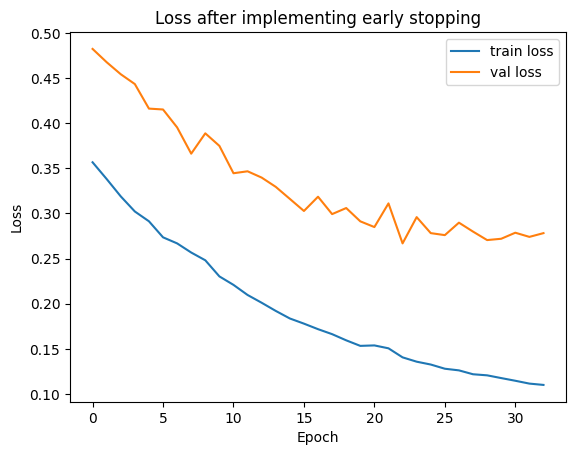

In [17]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.title('Loss after implementing early stopping')
plt.xlabel('Epoch')
plt.ylabel('Loss')